In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv('Social_Network_Ads.csv')
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
data.shape

(400, 3)

In [ ]:
X=data.iloc[:,0:2]
y=data.iloc[:,-1]

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
import numpy as np
np.round(X_train.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,37.8,69359.4
std,10.4,33969.7
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,69500.0
75%,46.0,87000.0
max,60.0,150000.0


In [ ]:
X_train_scaled = pd.DataFrame(data=X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(data=X_test_scaled, columns=X_test.columns)

In [ ]:
np.round(X_train_scaled.describe(), 1)

,Age,EstimatedSalary
count,320.0,320.0
mean,0.5,0.4
std,0.2,0.3
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.4
75%,0.7,0.5
max,1.0,1.0


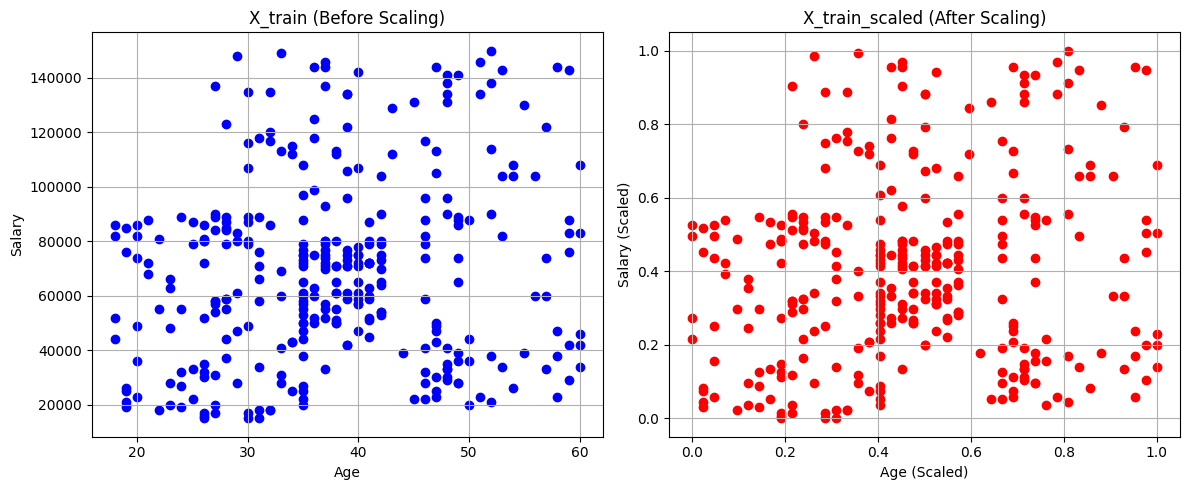

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ---------------- BEFORE SCALING ----------------
plt.subplot(1, 2, 1)
plt.scatter(X_train['Age'], X_train['EstimatedSalary'], color='blue')
plt.title('X_train (Before Scaling)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.grid(True)

# ---------------- AFTER SCALING ----------------
plt.subplot(1, 2, 2)
plt.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='red')
plt.title('X_train_scaled (After Scaling)')
plt.xlabel('Age (Scaled)')
plt.ylabel('Salary (Scaled)')
plt.grid(True)

plt.tight_layout()
plt.show()

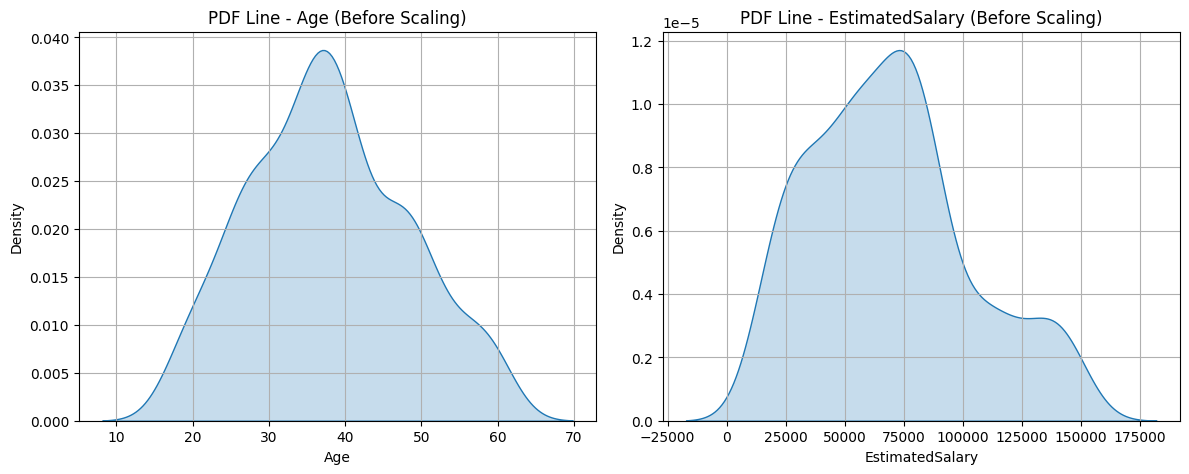

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))

# ---------------- AGE ----------------
plt.subplot(1, 2, 1)
sns.kdeplot(X_train['Age'], fill=True)
plt.title('PDF Line - Age (Before Scaling)')
plt.xlabel('Age')
plt.grid(True)

# ---------------- SALARY ----------------
plt.subplot(1, 2, 2)
sns.kdeplot(X_train['EstimatedSalary'], fill=True)
plt.title('PDF Line - EstimatedSalary (Before Scaling)')
plt.xlabel('EstimatedSalary')
plt.grid(True)

plt.tight_layout()
plt.show()

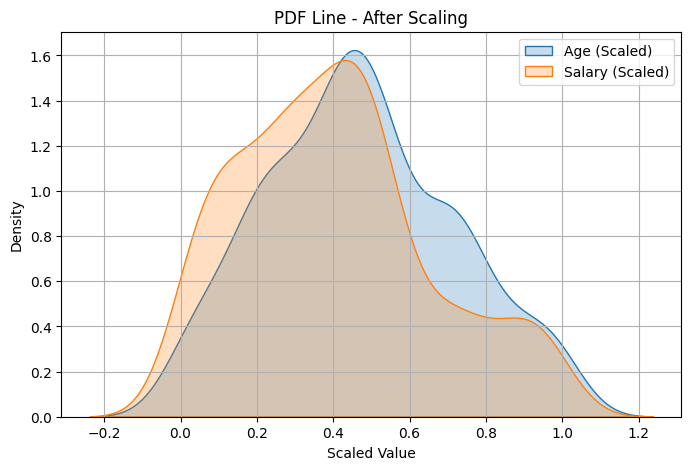

In [ ]:
plt.figure(figsize=(8,5))

sns.kdeplot(X_train_scaled['Age'], label='Age (Scaled)', fill=True)
sns.kdeplot(X_train_scaled['EstimatedSalary'], label='Salary (Scaled)', fill=True)

plt.title('PDF Line - After Scaling')
plt.xlabel('Scaled Value')
plt.ylabel('Density')

plt.legend()
plt.grid(True)

In [ ]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [ ]:
lr.fit(X_train, y_train)
lr_scaled.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import accuracy_score
print("Accuracy without scaling {:.2f}%".format(accuracy_score(y_test, y_pred) * 100))
print("Accuracy with scaling {:.2f}%".format(accuracy_score(y_test, y_pred_scaled) * 100))

Accuracy without scaling 81.25%
Accuracy with scaling 81.25%
